# Punto 5 — ¿Puede un ESP32 usar un LLM? Restricciones

**Pregunta:** suponga una aplicación con un microcontrolador, por ejemplo un ESP32. ¿Podría usar un LLM? ¿Qué restricciones tendría?

## Respuesta corta
- **Un LLM "de verdad" (ChatGPT, Llama, etc.) no puede correr en un ESP32.** Ni de cerca.
- **Un modelo diminuto sí**, con muchas concesiones. Hay proyectos públicos que portan `llama2.c` (Karpathy) al ESP32-S3 y ejecutan un modelo de **260 mil parámetros** entrenado con TinyStories (cuentos infantiles muy simples) a unos **19 tokens/s** con 2 MB de PSRAM, y otros portes con modelos de unos pocos millones de parámetros. Los propios autores lo describen como una demostración "probablemente no muy útil".
- **En una aplicación real**, lo habitual es que el ESP32 sea el *cliente* de un LLM que corre en otro lado (nube o un servidor local con Ollama). El ESP32 hace lo que sabe hacer bien: leer sensores, filtrar y enviar poco.

Este notebook demuestra esas conclusiones con números.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Memorias típicas del ESP32 (en MB aprox.)
memoria_esp32 = {
    "SRAM interna (~520 KB)":              0.5,
    "PSRAM de una placa S3 N16R8 (8 MB)":  8,
    "Flash de una placa S3 N16R8 (16 MB)": 16,
}
for k, v in memoria_esp32.items():
    print(f"{k:40s} {v:>5} MB")

# Un celular modesto, para comparar
print(f"\n{'RAM de un celular modesto (4 GB)':40s} {4000:>5} MB")

SRAM interna (~520 KB)                     0.5 MB
PSRAM de una placa S3 N16R8 (8 MB)           8 MB
Flash de una placa S3 N16R8 (16 MB)         16 MB

RAM de un celular modesto (4 GB)          4000 MB


**Qué hace:** fija los datos de partida. Un ESP32 tiene **menos de 1 MB de RAM interna** (la memoria rápida). Algunas placas añaden **PSRAM externa** (2 a 8 MB) y **flash** (4 a 16 MB) para guardar el programa y datos, pero ambas son bastante más lentas que la RAM interna. Para comparar, un celular modesto tiene miles de veces más memoria.

In [2]:
# Tamaño en memoria de los PESOS de distintos modelos (solo parámetros, sin contar activaciones)
modelos = {                      # millones de parámetros
    "TinyStories 260K":      0.26,
    "TinyStories 3.3M":      3.3,
    "TinyStories 15M":       15,
    "TinyStories 110M":      110,
    "GPT-2 small":           124,
    "Llama 3.2 1B":          1240,
    "Llama 3.1 8B":          8030,
}
bytes_por_parametro = {"fp32": 4, "int8": 1, "int4": 0.5}     # precisión numérica

tabla = pd.DataFrame(
    {prec: {m: p * b for m, p in modelos.items()} for prec, b in bytes_por_parametro.items()}
)
tabla.columns = [f"MB en {c}" for c in tabla.columns]

PSRAM_UTIL = 0.75 * memoria_esp32["PSRAM de una placa S3 N16R8 (8 MB)"]   # dejamos 25% para activaciones y caché
tabla["¿Cabe en PSRAM de 8 MB? (int8)"] = np.where(tabla["MB en int8"] <= PSRAM_UTIL, "SÍ", "no")
tabla["¿Cabe en flash de 16 MB? (int8)"] = np.where(tabla["MB en int8"] <= 16, "SÍ", "no")
tabla.round(2)

,MB en fp32,MB en int8,MB en int4,¿Cabe en PSRAM de 8 MB? (int8),¿Cabe en flash de 16 MB? (int8)
TinyStories 260K,1.04,0.26,0.13,SÍ,SÍ
TinyStories 3.3M,13.20,3.30,1.65,SÍ,SÍ
TinyStories 15M,60.00,15.00,7.50,no,SÍ
TinyStories 110M,440.00,110.00,55.00,no,no
GPT-2 small,496.00,124.00,62.00,no,no
Llama 3.2 1B,4960.00,1240.00,620.00,no,no
Llama 3.1 8B,32120.00,8030.00,4015.00,no,no


**Qué hace:** calcula cuánta memoria ocupan **solo los pesos** de varios modelos: parámetros × bytes por parámetro.
- `fp32` usa 4 bytes por parámetro (precisión completa); `int8` usa 1 byte y `int4` medio byte. Esto se llama **cuantización**: es la técnica que más ayuda a reducir el tamaño, a costa de algo de precisión.
- Se reserva el 25% de la PSRAM para activaciones y caché, porque los pesos no son lo único que hay que guardar.

Conclusión de la tabla: solo los modelos de **unos pocos millones de parámetros** caben en un ESP32 con PSRAM. Incluso un modelo "pequeño" como Llama 3.2 1B necesita cientos de MB aun cuantizado a 4 bits.

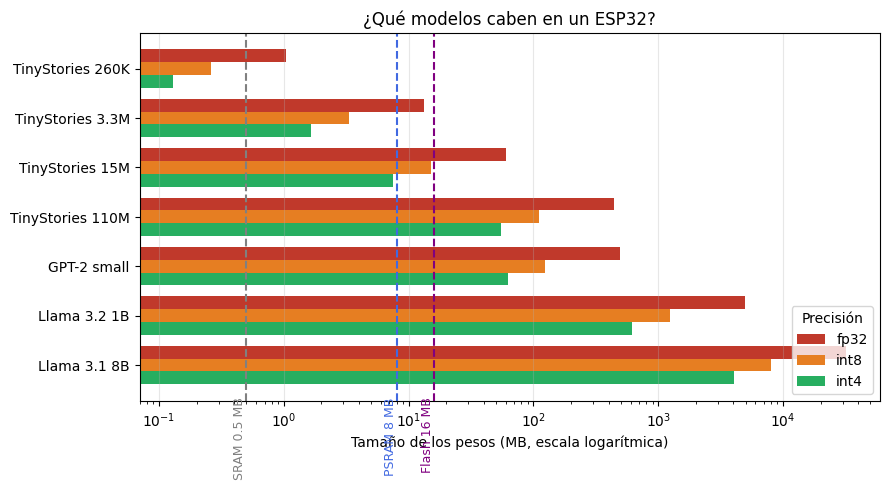

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(modelos))
alto = 0.26
ax.barh(y - alto, tabla["MB en fp32"], alto, label="fp32", color="#c0392b")
ax.barh(y,        tabla["MB en int8"], alto, label="int8", color="#e67e22")
ax.barh(y + alto, tabla["MB en int4"], alto, label="int4", color="#27ae60")

for nombre, mb, color in [("SRAM 0.5 MB", 0.5, "gray"), ("PSRAM 8 MB", 8, "royalblue"), ("Flash 16 MB", 16, "purple")]:
    ax.axvline(mb, linestyle="--", color=color)
    ax.text(mb, len(modelos) - 0.35, nombre, rotation=90, va="top", ha="right", color=color, fontsize=9)

ax.set_xscale("log")
ax.set_yticks(y); ax.set_yticklabels(list(modelos.keys()))
ax.invert_yaxis()
ax.set_xlabel("Tamaño de los pesos (MB, escala logarítmica)")
ax.set_title("¿Qué modelos caben en un ESP32?")
ax.legend(title="Precisión", loc="lower right"); ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

**Qué hace:** grafica la tabla en escala logarítmica. Las líneas verticales son las memorias del ESP32: lo que queda **a la izquierda de una línea cabe** en esa memoria. Se ve que hay un salto de varios órdenes de magnitud entre lo que el chip puede guardar y lo que ocupan los LLM reales.

In [4]:
# ¿A qué velocidad generaría texto?
# Para generar cada token hay que LEER todos los pesos de la memoria una vez, así que:
#     tokens/s  ≈  ancho_de_banda_de_memoria / tamaño_del_modelo
ANCHO_BANDA_PSRAM = 40   # MB/s, orden de magnitud: sale de un proyecto público con modelo int8 de 3.3M
                         # (~12 tokens/s, cerca de su límite teórico de ~13 tokens/s -> ~43 MB/s)

def tokens_por_segundo(mb_modelo, ancho_banda=ANCHO_BANDA_PSRAM):
    return ancho_banda / mb_modelo

print(f"{'Modelo':20s} {'MB (int8)':>10s}   Velocidad máxima estimada")
for nombre in modelos:
    mb = tabla.loc[nombre, "MB en int8"]
    if mb <= PSRAM_UTIL:
        print(f"{nombre:20s} {mb:10.2f}   ~{tokens_por_segundo(mb):.0f} tokens/s")
    else:
        print(f"{nombre:20s} {mb:10.1f}   no cabe en PSRAM")

Modelo                MB (int8)   Velocidad máxima estimada
TinyStories 260K           0.26   ~154 tokens/s
TinyStories 3.3M           3.30   ~12 tokens/s
TinyStories 15M            15.0   no cabe en PSRAM
TinyStories 110M          110.0   no cabe en PSRAM
GPT-2 small               124.0   no cabe en PSRAM
Llama 3.2 1B             1240.0   no cabe en PSRAM
Llama 3.1 8B             8030.0   no cabe en PSRAM


**Qué hace:** estima la velocidad. Generar un token obliga a leer todos los pesos de la memoria, así que la velocidad queda limitada por el **ancho de banda de la memoria**, no por el procesador: `tokens/s ≈ ancho de banda / tamaño del modelo`.

Ese ancho de banda (~40 MB/s) lo tomé como orden de magnitud de proyectos públicos de `llama2.c` en ESP32-S3; es una estimación, no una medida mía. Sirve para ver la tendencia: un modelo 10 veces más grande es ~10 veces más lento. (Para modelos muy pequeños, el límite real pasa a ser el cálculo, por eso el dato de 260K es solo un techo teórico.)

In [ ]:
# Además de los pesos, hace falta la "memoria de contexto" (KV cache)
def kv_cache_mb(capas, contexto, dim_kv, bytes_por_valor):
    # 2 (llaves y valores) x capas x tokens de contexto x dimensión x bytes
    return 2 * capas * contexto * dim_kv * bytes_por_valor / 1e6

# Valores aproximados de la arquitectura de Llama 3.2 1B (16 capas, dimensión KV = 512), en fp16
for contexto in (128, 512, 2048):
    mb = kv_cache_mb(capas=16, contexto=contexto, dim_kv=512, bytes_por_valor=2)
    print(f"Contexto de {contexto:>5} tokens -> KV cache ≈ {mb:6.1f} MB")

**Qué hace:** calcula una restricción que se olvida con frecuencia. Además de los pesos, el modelo guarda las llaves y valores de la atención (los K y V que explica el documento) de todos los tokens ya procesados: la **KV cache**. Crece con la longitud del contexto, y con un contexto de 2048 tokens ya ocupa más memoria que todo lo que tiene la placa. Por eso en un ESP32 el contexto tendría que ser cortísimo.

In [ ]:
# Una arquitectura más realista: el ESP32 decide cuándo llamar al LLM
rng = np.random.default_rng(3)

# Simulamos 24 h de vibración de una bomba, una lectura cada 5 s (RMS en g)
lecturas = rng.normal(0.40, 0.08, size=24 * 3600 // 5)
lecturas[10000:10040] += 0.6          # una falla real: vibración alta durante ~3 minutos

UMBRAL_ALERTA = 0.85
alertas = np.where(lecturas > UMBRAL_ALERTA)[0]
print(f"Lecturas del día:          {len(lecturas)}")
print(f"Lecturas que activan alerta: {len(alertas)}")
print(f"Llamadas al LLM si se enviara todo: {len(lecturas)}  vs  solo en alerta: {1 if len(alertas) else 0}")

# Qué enviaría el ESP32: un resumen pequeño, no los datos crudos
import json
resumen = {"equipo": "BOMBA-07", "rms_g": round(float(lecturas[alertas[0]]), 2),
           "umbral_g": UMBRAL_ALERTA, "temp_c": 71.5, "alerta": "vibracion_alta"}
carga = json.dumps(resumen)
crudo = 3 * 1000 * 2    # 3 ejes x 1000 muestras/s x 2 bytes, solo 1 segundo de señal cruda
print(f"\nMensaje al LLM: {carga}")
print(f"Tamaño: {len(carga)} bytes  (vs {crudo} bytes de 1 s de señal cruda)")

**Qué hace:** simula la forma recomendada de usar IA generativa con un microcontrolador. El ESP32 lee un sensor de vibración cada 5 segundos y aplica una **regla simple en el propio chip** (un umbral; podría ser un modelo TinyML pequeño). Solo cuando detecta una anomalía envía un **resumen de unos 100 bytes** a un LLM externo, que redacta la orden de trabajo.

Resultado: de miles de lecturas al día se pasa a una sola consulta al LLM. Esto conecta con el punto 4 del documento (agente de mantenimiento): el ESP32 es el sensor y el LLM es el cerebro que redacta la orden.

## Cómo conectaría el ESP32 con un LLM externo

Ejemplo ilustrativo en **MicroPython** (no se ejecuta aquí; hay que probarlo en la placa) que llama a un servidor Ollama en la red local:

```python
import network, urequests, ujson, time

wlan = network.WLAN(network.STA_IF)
wlan.active(True)
wlan.connect("MI_WIFI", "MI_CLAVE")
while not wlan.isconnected():
    time.sleep(0.5)

def pedir_orden_de_trabajo(resumen):
    prompt = "Eres un asistente de mantenimiento. Redacta una orden de trabajo breve para: " + ujson.dumps(resumen)
    r = urequests.post(
        "http://192.168.1.50:11434/api/generate",        # PC o Raspberry Pi con Ollama
        data=ujson.dumps({"model": "llama3.2:3b", "prompt": prompt, "stream": False}),
        headers={"Content-Type": "application/json"})
    texto = r.json()["response"]
    r.close()
    return texto
```

## Opciones de arquitectura

| Opción | Dónde corre el LLM | Ventajas | Desventajas |
|---|---|---|---|
| **A. LLM minúsculo en el chip** | En el ESP32 (≤ unos pocos M de parámetros) | Sin red, sin costo por uso, privado | Solo texto muy simple; no sirve para chat general ni razonar |
| **B. ESP32 como cliente de la nube** | API de un proveedor | Modelos potentes | Requiere WiFi, latencia, costo por token, datos salen de la planta, hay que proteger las claves (mejor usar un servidor intermedio) |
| **C. Servidor local (Ollama en PC/Raspberry Pi)** | En la red de la planta | Privado, sin costo por token, sin internet | Hay que mantener el servidor |
| **D. TinyML en el chip + LLM externo** | Decisión simple en el chip, lenguaje fuera | Eficiente en energía y datos, lo más realista | Dos sistemas que integrar |

## Restricciones, resumidas

| Restricción | Por qué importa |
|---|---|
| **Memoria** | < 1 MB de RAM interna, 2-8 MB de PSRAM en algunas placas; los LLM reales necesitan cientos de MB a decenas de GB |
| **Ancho de banda de memoria** | Cada token exige leer todos los pesos; la PSRAM es lenta, así que la generación es lenta aun con modelos mínimos |
| **Cómputo** | Dos núcleos a 240 MHz, sin GPU ni acelerador de matrices (el ESP32-S3 tiene algunas instrucciones vectoriales que ayudan) |
| **Contexto (KV cache)** | Crece con el largo del texto; en el chip el contexto sería de unas decenas o pocos cientos de tokens |
| **Calidad del modelo** | Un modelo de ~1M de parámetros solo genera frases simples; no razona ni sigue instrucciones complejas |
| **Cuantización** | Imprescindible (int8/int4) y reduce la precisión |
| **Energía y calor** | Un uso intensivo de CPU gasta batería, lo que va contra la ventaja principal de un microcontrolador |
| **Software** | Hay que escribir o portar el motor de inferencia en C (por ejemplo, ESP-IDF + `llama2.c`); no se usan directamente las herramientas habituales de IA |

## Conclusión
Un ESP32 **puede ejecutar un LLM diminuto como demostración**, pero no un LLM útil para conversar o razonar. La forma práctica de combinar ambos mundos es que el microcontrolador haga la lectura de sensores y la decisión simple, y que un LLM en un servidor haga la parte de lenguaje.